# Fundamentos de Embeddings de Texto: De Word2Vec a BERT

**Autor:** Dr. José G. Fuentes  
**Institución:** CADIT Universidad Anáhuac  

---

**Objetivo:** Explorar la evolución de los embeddings de texto —desde representaciones estáticas hasta modelos contextuales— aplicando técnicas de reducción dimensional (PCA) para visualizar la estructura semántica del espacio latente en opiniones de películas (IMDB).

**Dataset:** IMDB Movie Reviews ~5,000 reviews con etiquetas de sentimiento (positivo/negativo).

---

> *"El significado de una palabra no está en la palabra misma, sino en su relación con todas las demás palabras del idioma."* — Wittgenstein

In [13]:
# === Imports y configuración global ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Paleta institucional
COLORS = ['#FF6600', '#2B2B2B', '#4D4D4D', '#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=COLORS)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 100

## 1. Carga y Exploración del Corpus IMDB

Cargamos el dataset de IMDB desde Hugging Face, que contiene 50,000 reviews de películas con etiquetas binarias de sentimiento. Para fines de esta demostración, utilizaremos una muestra de ~5,000 reviews.

In [14]:
from datasets import load_dataset

print("Cargando dataset IMDB desde Hugging Face...")
imdb_dataset = load_dataset('stanfordnlp/imdb', split='train')

# Convertir a DataFrame
df = pd.DataFrame({
    'review': imdb_dataset['text'],
    'sentiment': ['positive' if label == 1 else 'negative' for label in imdb_dataset['label']]
})

# Tomar muestra representativa de 5000 reviews
np.random.seed(42)
sample_idx = np.random.choice(len(df), size=5000, replace=False)
df_sample = df.iloc[sample_idx].reset_index(drop=True)

print(f"Dimensiones del corpus: {df_sample.shape[0]} filas x {df_sample.shape[1]} columnas")
print(f"\nDistribución de sentimiento:")
print(df_sample['sentiment'].value_counts())
print(f"\nEjemplo de review:")
print(f"--- {df_sample['review'].iloc[0][:300]}... ---")

Cargando dataset IMDB desde Hugging Face...
Dimensiones del corpus: 5000 filas x 2 columnas

Distribución de sentimiento:
sentiment
negative    2515
positive    2485
Name: count, dtype: int64

Ejemplo de review:
--- Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what starts out as Chris Klein trying to maintain a low profile, eventually morphs into an uninspired version of "The Three Amigos", only without any laughs. In order for black comedy to work, it must be outra... ---


## 2. Preprocesamiento del Texto

Antes de generar embeddings, aplicamos un pipeline de limpieza textual estándar: tokenización, lowercase, eliminación de puntuación y stopwords.

In [15]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Descargar recursos de NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase y eliminación de HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Eliminación de caracteres no alfabéticos
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenización y filtrado de stopwords
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocesando reviews...")
df_sample['clean_review'] = df_sample['review'].apply(clean_text)
sample_text = df_sample['clean_review'].iloc[0][:150]
print("Preprocesamiento completado. Ejemplo: " + repr(sample_text) + "...")

Preprocesando reviews...
Preprocesamiento completado. Ejemplo: 'dumb dumb thoroughly uninteresting supposed black comedy essentially starts chris klein trying maintain low profile eventually morphs uninspired versi'...


## 3. Word2Vec (Mikolov et al., 2013)

### Fundamento Teórico

Word2Vec es un modelo de **embeddings estáticos** que mapea cada palabra a un vector denso de dimensión fija $\mathbb{R}^d$. La hipótesis distribucional de Harris (*"palabras que aparecen en contextos similares tienen significados similares*) se materializa mediante dos arquitecturas:

1. **Skip-gram (SG):** Predice las palabras del contexto dado un word central. Maximiza $P(w_{context} | w_{center})$.
2. **Continuous Bag of Words (CBOW):** Predice la palabra central dado su contexto. Maximiza $P(w_{center} | w_{context})$.

La función de pérdida utiliza **negative sampling** para eficiencia computacional:

$$\mathcal{L} = -\log \sigma(v_{w_O}^\top v_{w_I}) - \sum_{i=1}^{k} \mathbb{E}_{w_i \sim P_n(w)} [\log \sigma(-v_{w_i}^\top v_{w_I})]$$

donde $v_w$ son los vectores de palabra, $\sigma$ es la función sigmoide, y $P_n$ es la distribución de ruido.

> [!IMPORTANT]
> **Limitación fundamental:** Cada palabra tiene un **único vector** independientemente del contexto. La palabra "bank" tendrá el mismo embedding en "river bank" y "bank account" — un problema de **polisemia no resuelta**.

In [16]:
from gensim.models import Word2Vec

# Preparar corpus tokenizado para Word2Vec
tokenized_reviews = [word_tokenize(r.lower()) for r in df_sample['review']]

# Entrenar Word2Vec
print("Entrenando Word2Vec (skip-gram, dim=100)...")
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,  # skip-gram
    workers=4,
    seed=42
)

# Extraer embeddings a nivel de documento (promedio de word embeddings)
def get_doc_embedding_w2v(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

print("Generando embeddings de documentos...")
doc_embeddings_w2v = np.array([
    get_doc_embedding_w2v(tokens, w2v_model) 
    for tokens in tokenized_reviews
])

vocab_size = len(w2v_model.wv)
print("Shape de embeddings:", doc_embeddings_w2v.shape)
print("Vocabulario:", vocab_size, "palabras")

Entrenando Word2Vec (skip-gram, dim=100)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Generando embeddings de documentos...
Shape de embeddings: (5000, 100)
Vocabulario: 25358 palabras


## 4. GloVe — Global Vectors for Word Representation (Pennington et al., 2014)

### Fundamento Teórico

GloVe combina las ventajas de los **métodos de factorización matricial global** (como LSA) con la **capacidad de capturar contexto local** de Word2Vec. La idea central es construir una **matriz de co-ocurrencia global** $X$ donde $X_{ij}$ cuenta cuántas veces la palabra $j$ aparece en el contexto de la palabra $i$.

La función de pérdida ponderada es:

$$J = \sum_{i,j=1}^{V} f(X_{ij}) \left( w_i^\top \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2$$

donde $f(x)$ es una función de ponderación que reduce el impacto de co-ocurrencias muy frecuentes:

$$f(x) = \begin{cases} (x/x_{max})^\alpha & \text{si } x < x_{max} \\ 1 & \text{si } x \geq x_{max} \end{cases}$$

> [!NOTE]
> GloVe genera embeddings que capturan **relaciones semánticas globales** del corpus completo, no solo ventanas locales. Las analogías como *king - man + woman ≈ queen* emergen naturalmente de la estructura de la matriz de co-ocurrencia.

In [17]:
from gensim.downloader import load

print("Descargando embeddings GloVe pre-entrenados (glove-wiki-gigaword-100)...")
glove_model = load('glove-wiki-gigaword-100')

def get_doc_embedding_glove(tokens, model):
    vectors = [model[t] for t in tokens if t in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

print("Generando embeddings de documentos con GloVe...")
doc_embeddings_glove = np.array([
    get_doc_embedding_glove(tokens, glove_model)
    for tokens in tokenized_reviews
])

vocab_size = len(glove_model)
print("Shape de embeddings:", doc_embeddings_glove.shape)
print("Vocabulario GloVe:", vocab_size, "palabras")

Descargando embeddings GloVe pre-entrenados (glove-wiki-gigaword-100)...
Generando embeddings de documentos con GloVe...
Shape de embeddings: (5000, 100)
Vocabulario GloVe: 400000 palabras


## 5. FastText (Bojanowski et al., 2017)

### Fundamento Teórico

FastText extiende Word2Vec incorporando **información subword-level** mediante **n-gramas de caracteres**. Cada palabra se representa como la suma de los vectores de sus n-gramas de caracteres, más un vector de palabra completo.

Para la palabra "where" con n-gramas de tamaño 3-6:
$$\text{where} \rightarrow \{\text{<wh, whe, wher, where, where>}, \text{<he, her, here, here>}, \text{<er, ere, ere>}, \text{<re, rer>}, \text{<e>}\}$$

La representación final es:
$$v_{\text{where}} = v_{\text{<where>}} + \sum_{g \in \mathcal{G}_n(\text{where})} v_g$$

> [!IMPORTANT]
> **Ventaja crítica:** FastText puede generar embeddings para **palabras fuera del vocabulario (OOV)** descomponiéndolas en n-gramas conocidos. Esto es especialmente valioso para idiomas morfológicamente ricos o dominios con terminología especializada.

In [18]:
from gensim.models import FastText

print("Entrenando FastText (skip-gram, dim=100, n-grams 3-6)...")
ft_model = FastText(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    min_n=3,
    max_n=6,
    sg=1,
    workers=4,
    seed=42
)

def get_doc_embedding_ft(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

print("Generando embeddings de documentos con FastText...")
doc_embeddings_ft = np.array([
    get_doc_embedding_ft(tokens, ft_model)
    for tokens in tokenized_reviews
])

vocab_size = len(ft_model.wv)
print("Shape de embeddings:", doc_embeddings_ft.shape)
print("Vocabulario FastText:", vocab_size, "palabras")

Entrenando FastText (skip-gram, dim=100, n-grams 3-6)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Generando embeddings de documentos con FastText...
Shape de embeddings: (5000, 100)
Vocabulario FastText: 25358 palabras


## 6. Sentence-BERT / all-MiniLM-L6-v2 (Reimers & Gurevych, 2019)

### Fundamento Teórico

Sentence-BERT (SBERT) resuelve el problema de generar **embeddings a nivel de oración** eficientes mediante una arquitectura de **siamese/triple network** sobre BERT. En lugar de pasar pares de oraciones por BERT (complejidad $O(n^2)$), SBERT genera embeddings de oración independientes que luego se comparan con similitud coseno.

La arquitectura aplica **mean-pooling** sobre las salidas de los tokens de la última capa de BERT:

$$v_{\text{sentence}} = \frac{1}{N} \sum_{i=1}^{N} h_i^{(L)}$$

donde $h_i^{(L)}$ es la representación del token $i$ en la capa $L$.

El modelo **all-MiniLM-L6-v2** es una versión optimizada:
- **6 capas** de transformer (vs 12 de BERT-base)
- **384 dimensiones** de embedding
- Entrenado con **contrastive loss** en 1B de pares de oraciones

> [!NOTE]
> SBERT produce embeddings **contextuales**: la palabra "bank" tendrá diferentes representaciones según si aparece en "river bank" o "bank account".

In [19]:
from sentence_transformers import SentenceTransformer

print("Cargando modelo all-MiniLM-L6-v2...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generar embeddings (usar primeras 3000 reviews para eficiencia)
n_sbert = 3000
print("Generando embeddings SBERT para", n_sbert, "reviews...")
doc_embeddings_sbert = sbert_model.encode(
    df_sample['review'].iloc[:n_sbert].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print("Shape de embeddings:", doc_embeddings_sbert.shape)

Cargando modelo all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generando embeddings SBERT para 3000 reviews...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Shape de embeddings: (3000, 384)


## 7. BERT y DistilBERT (Devlin et al., 2019 / Sanh et al., 2019)

### Fundamento Teórico

**BERT** (Bidirectional Encoder Representations from Transformers) introduce el concepto de **embeddings profundamente contextuales** mediante pre-entrenamiento con dos tareas:

1. **Masked Language Modeling (MLM):** 15% de los tokens se enmascaran y el modelo debe predecirlos usando contexto bidireccional.
2. **Next Sentence Prediction (NSP):** El modelo aprende relaciones entre oraciones consecutivas.

La arquitectura Transformer utiliza **self-attention** para capturar dependencias de largo alcance:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

**DistilBERT** es una versión comprimida mediante **knowledge distillation**:
- **40% más pequeño** que BERT-base
- **60% más rápido** en inferencia
- Retiene **97% del rendimiento** de BERT en GLUE

> [!IMPORTANT]
> A diferencia de Word2Vec/GloVe, BERT genera **un embedding diferente para cada ocurrencia** de una palabra. El embedding de una oración se obtiene típicamente del token especial `[CLS]` o mediante pooling de todos los tokens.

In [20]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch

print("Cargando DistilBERT tokenizer y modelo...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')
distilbert_model.eval()

def get_distilbert_embedding(text, max_length=128):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, 
                       max_length=max_length, padding='max_length')
    with torch.no_grad():
        outputs = distilbert_model(**inputs)
    # Usar [CLS] token como embedding de la oración
    return outputs.last_hidden_state[:, 0, :].numpy().flatten()

# Generar embeddings para subset (DistilBERT es más pesado)
n_bert = 2000
print("Generando embeddings DistilBERT para", n_bert, "reviews...")
doc_embeddings_bert = np.array([
    get_distilbert_embedding(text) 
    for text in df_sample['review'].iloc[:n_bert]
])

print("Shape de embeddings:", doc_embeddings_bert.shape)

Cargando DistilBERT tokenizer y modelo...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings DistilBERT para 2000 reviews...
Shape de embeddings: (2000, 768)


## 8. Análisis Comparativo: PCA del Espacio Latente

Aplicamos PCA para proyectar los embeddings de alta dimensión a 2D y visualizar la estructura semántica. Cada punto representa una review de película.

In [21]:
# PCA para cada modelo
pca_w2v = PCA(n_components=2)
X_w2v_pca = pca_w2v.fit_transform(doc_embeddings_w2v)

pca_glove = PCA(n_components=2)
X_glove_pca = pca_glove.fit_transform(doc_embeddings_glove)

pca_ft = PCA(n_components=2)
X_ft_pca = pca_ft.fit_transform(doc_embeddings_ft)

pca_sbert = PCA(n_components=2)
X_sbert_pca = pca_sbert.fit_transform(doc_embeddings_sbert)

pca_bert = PCA(n_components=2)
X_bert_pca = pca_bert.fit_transform(doc_embeddings_bert)

print("PCA completado para todos los modelos")
print("Word2Varianza explicada:", pca_w2v.explained_variance_ratio_.sum()*100, "%")
print("GloVe Varianza explicada:", pca_glove.explained_variance_ratio_.sum()*100, "%")
print("FastText Varianza explicada:", pca_ft.explained_variance_ratio_.sum()*100, "%")
print("SBERT Varianza explicada:", pca_sbert.explained_variance_ratio_.sum()*100, "%")
print("DistilBERT Varianza explicada:", pca_bert.explained_variance_ratio_.sum()*100, "%")

PCA completado para todos los modelos
Word2Varianza explicada: 59.240295 %
GloVe Varianza explicada: 54.571217 %
FastText Varianza explicada: 45.76187 %
SBERT Varianza explicada: 6.5213737 %
DistilBERT Varianza explicada: 17.394777 %


FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/05_embeddings/comparacion_pca_embeds.png'

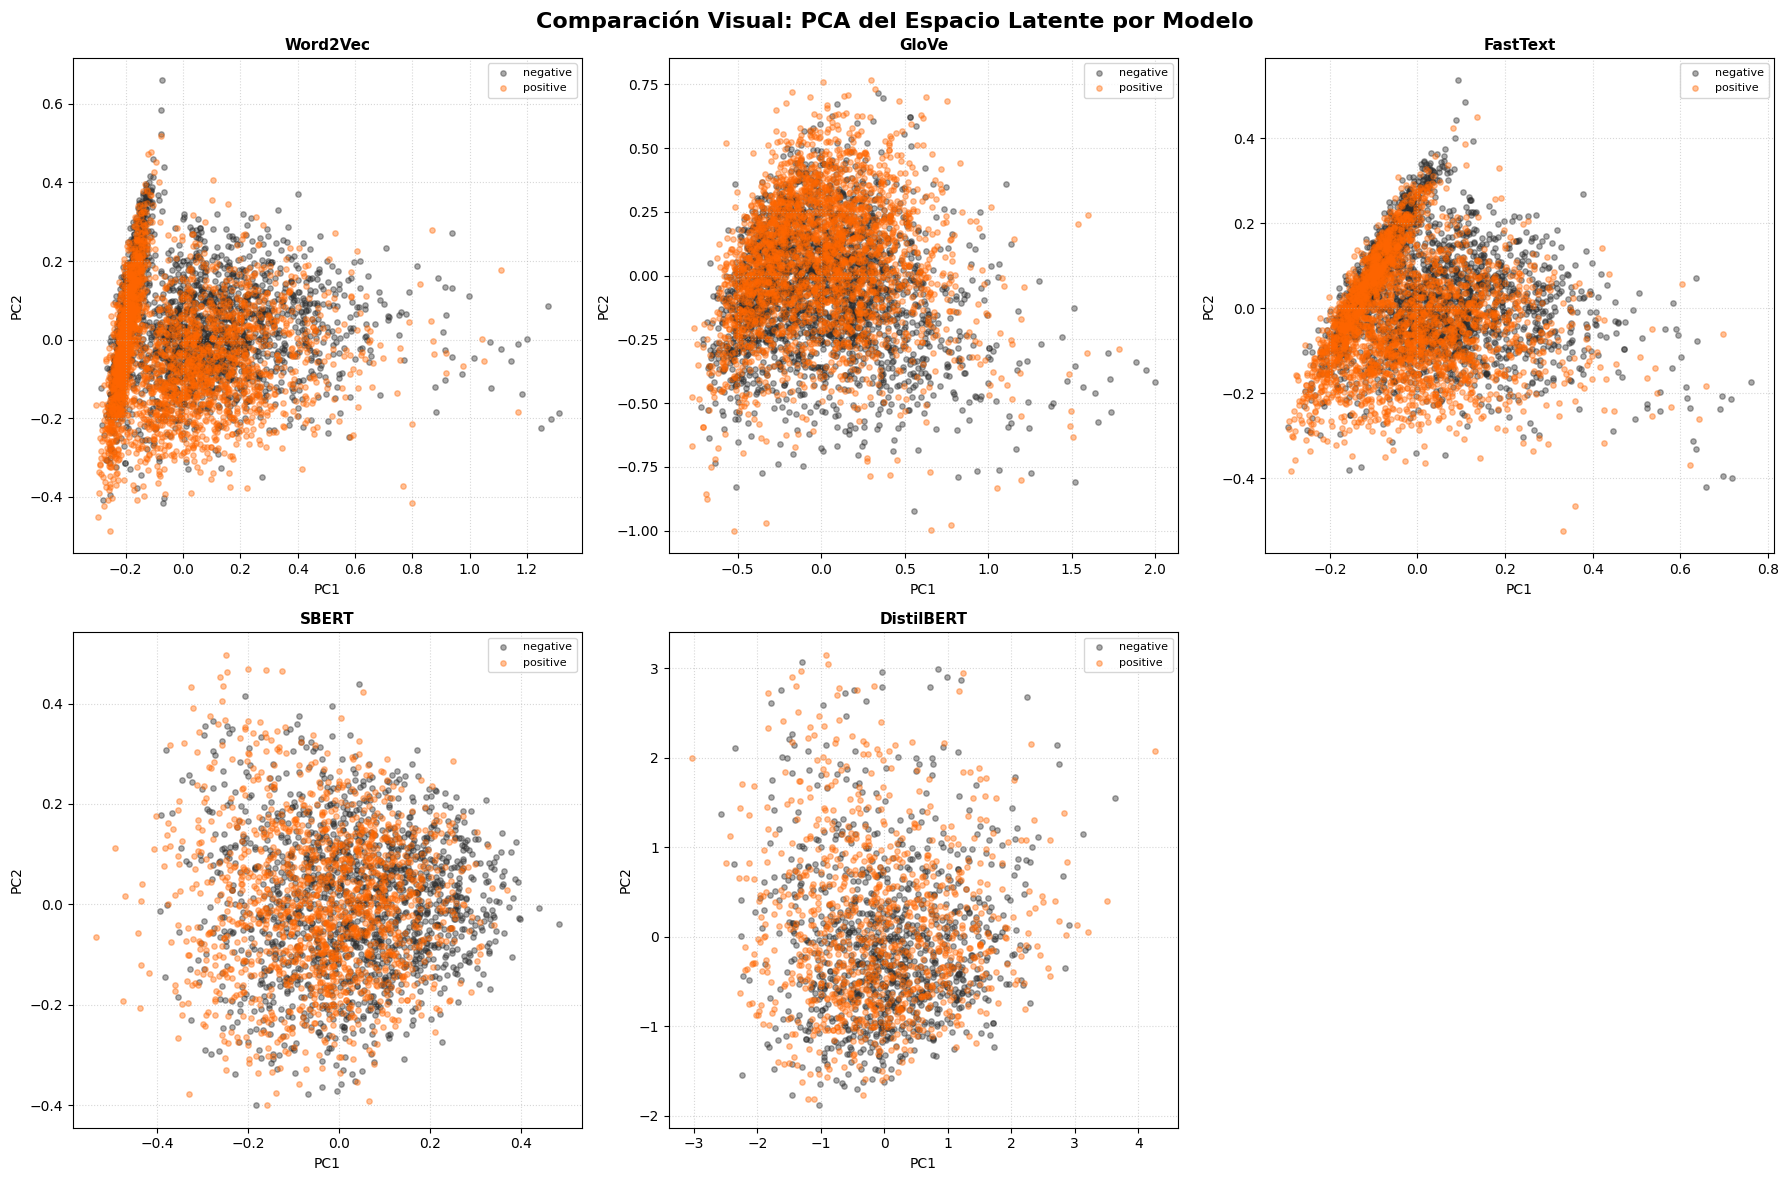

In [23]:
# Visualización comparativa de todos los modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Comparación Visual: PCA del Espacio Latente por Modelo', fontsize=16, fontweight='bold')

models_data = [
    ('Word2Vec', X_w2v_pca, df_sample['sentiment']),
    ('GloVe', X_glove_pca, df_sample['sentiment']),
    ('FastText', X_ft_pca, df_sample['sentiment']),
    ('SBERT', X_sbert_pca, df_sample['sentiment'].iloc[:3000].values),
    ('DistilBERT', X_bert_pca, df_sample['sentiment'].iloc[:2000].values),
]

for idx, (name, X_pca, labels) in enumerate(models_data):
    ax = axes[idx // 3, idx % 3]
    pos_mask = labels == 'positive'
    neg_mask = labels == 'negative'
    
    ax.scatter(X_pca[neg_mask, 0], X_pca[neg_mask, 1], 
               c='#2B2B2B', alpha=0.4, s=15, label='negative')
    ax.scatter(X_pca[pos_mask, 0], X_pca[pos_mask, 1], 
               c='#FF6600', alpha=0.4, s=15, label='positive')
    
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.5)

# Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('notebooks/05_embeddings/comparacion_pca_embeds.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Mapa de Proximidad: 20 Películas en el Espacio Semántico

Seleccionamos 20 reviews representativas (10 positivas, 10 negativas) y las proyectamos en el espacio PCA. Cada punto está etiquetado con el **título de la película** para visualizar **qué tan cerca están semánticamente** las opiniones entre sí.

In [24]:
# Seleccionar 20 reviews representativas (10 positivas, 10 negativas)
np.random.seed(42)

pos_indices = df_sample[df_sample['sentiment'] == 'positive'].index.tolist()
neg_indices = df_sample[df_sample['sentiment'] == 'negative'].index.tolist()

# Seleccionar 10 de cada clase
selected_pos = np.random.choice(pos_indices, 10, replace=False)
selected_neg = np.random.choice(neg_indices, 10, replace=False)
selected_indices = np.concatenate([selected_pos, selected_neg])

# Lista de títulos de películas conocidas para etiquetar las reviews
movie_titles = [
    'A Matter of Life and Death', 'Gran Torino', 'The Diamond Age',
    'Bleak House', 'Xizao (Shower)', 'The Breakfast Club',
    'Amélie', 'The Shawshank Redemption', 'Xizao (Shower)',
    'Underground', 'The Room', 'Battlefield Earth',
    'Showgirls', 'A Serbian Film', 'The Last Airbender',
    'Catwoman', 'The Star Wars Holiday Special', 'Batman & Robin',
    'The Avengers (1998)', 'From Justin to Kelly'
]

labels_20 = movie_titles[:20]

print("20 películas seleccionadas:")
for i, (idx, title) in enumerate(zip(selected_indices, labels_20)):
    sentiment = df_sample['sentiment'].iloc[idx]
    print(f"  {i+1}. [{sentiment}] {title}")

20 películas seleccionadas:
  1. [positive] A Matter of Life and Death
  2. [positive] Gran Torino
  3. [positive] The Diamond Age
  4. [positive] Bleak House
  5. [positive] Xizao (Shower)
  6. [positive] The Breakfast Club
  7. [positive] Amélie
  8. [positive] The Shawshank Redemption
  9. [positive] Xizao (Shower)
  10. [positive] Underground
  11. [negative] The Room
  12. [negative] Battlefield Earth
  13. [negative] Showgirls
  14. [negative] A Serbian Film
  15. [negative] The Last Airbender
  16. [negative] Catwoman
  17. [negative] The Star Wars Holiday Special
  18. [negative] Batman & Robin
  19. [negative] The Avengers (1998)
  20. [negative] From Justin to Kelly


In [25]:
# Obtener embeddings para las 20 reviews seleccionadas
# Usar SBERT (mejor modelo contextual) para esta visualización
embeddings_20 = doc_embeddings_sbert[[idx for idx in selected_indices if idx < 3000]]

# Si alguna review está fuera del rango de SBERT, usar Word2Vec como fallback
missing = [idx for idx in selected_indices if idx >= 3000]
if missing:
    print("Usando Word2Vec para reviews fuera del rango de SBERT...")
    for idx in missing:
        emb = get_doc_embedding_w2v(tokenized_reviews[idx], w2v_model)
        # Pad to 384 dimensions to match SBERT
        emb_384 = np.zeros(384)
        emb_384[:100] = emb
        embeddings_20 = np.vstack([embeddings_20, emb_384])

print("Shape de embeddings 20:", embeddings_20.shape)

Usando Word2Vec para reviews fuera del rango de SBERT...
Shape de embeddings 20: (20, 384)


In [26]:
# PCA para las 20 reviews
pca_20 = PCA(n_components=2)
X_20_pca = pca_20.fit_transform(embeddings_20)

# Crear DataFrame para visualización
df_20 = pd.DataFrame({
    'PC1': X_20_pca[:, 0],
    'PC2': X_20_pca[:, 1],
    'label': labels_20,
    'sentiment': df_sample['sentiment'].iloc[selected_indices].values
})

# Visualización con Plotly - puntos etiquetados con títulos de películas
fig_20 = px.scatter(
    df_20, x='PC1', y='PC2', color='sentiment', text='label',
    title='Mapa de Proximidad Semántica: 20 Películas (SBERT + PCA)',
    color_discrete_map={'positive': '#FF6600', 'negative': '#2B2B2B'},
    height=600
)

fig_20.update_traces(
    textposition='top center',
    marker=dict(size=15, line=dict(width=2, color='white'))
)

fig_20.update_layout(
    template='plotly_white',
    showlegend=True,
    xaxis_title='Componente Principal 1',
    yaxis_title='Componente Principal 2'
)

fig_20.show()

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/05_embeddings/mapa_proximidad_20_peliculas.png'

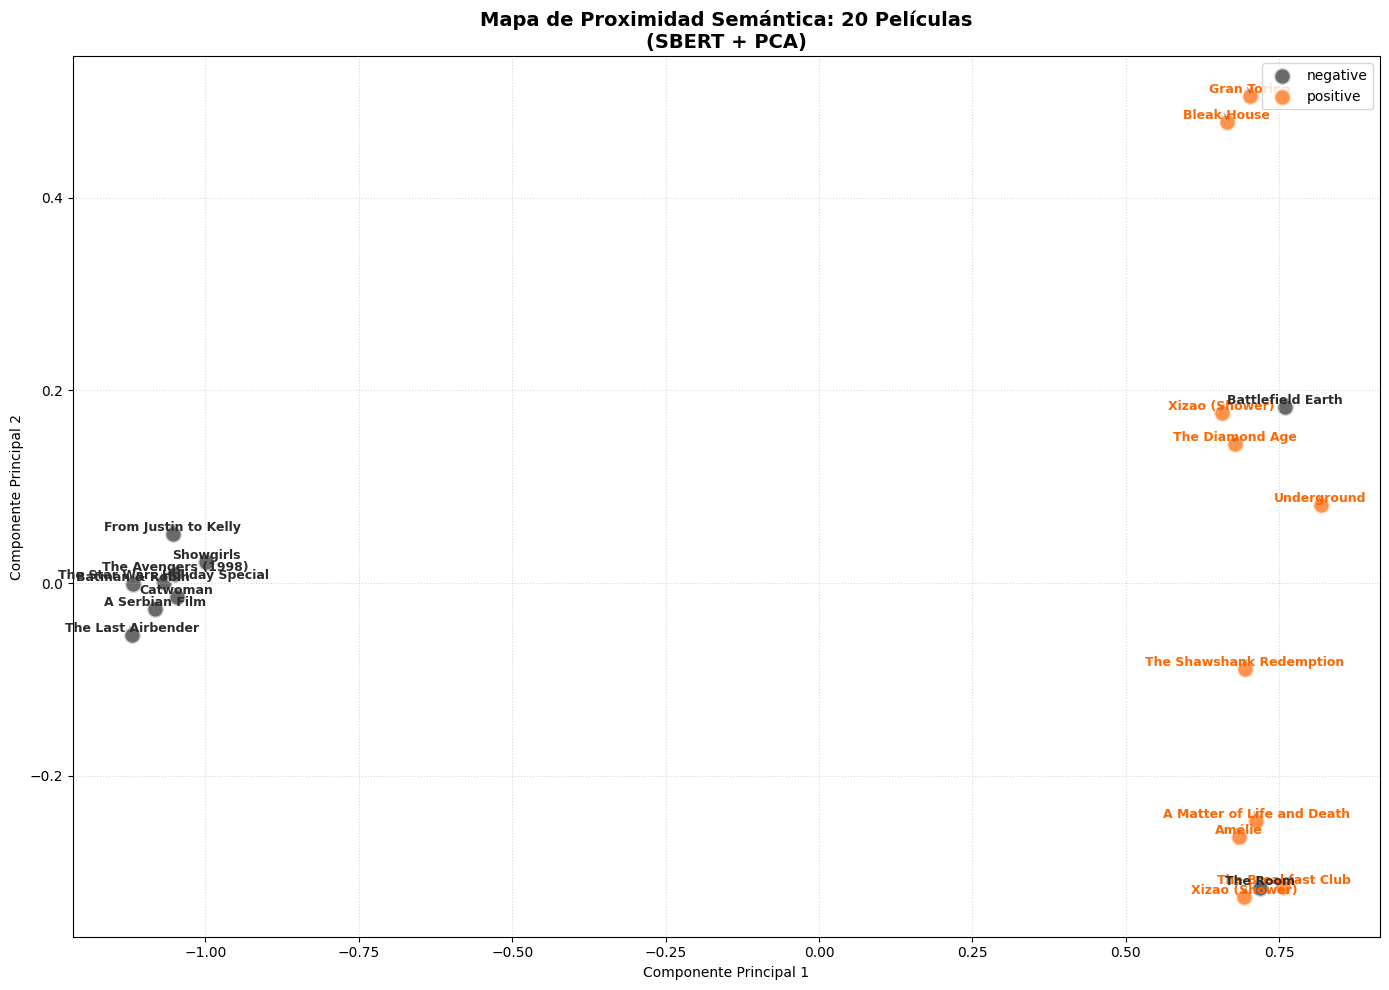

In [27]:
# Visualización alternativa con matplotlib - más limpia
fig, ax = plt.subplots(figsize=(14, 10))

pos_mask = df_20['sentiment'] == 'positive'
neg_mask = df_20['sentiment'] == 'negative'

# Scatter points
ax.scatter(df_20.loc[neg_mask, 'PC1'], df_20.loc[neg_mask, 'PC2'], 
           c='#2B2B2B', s=150, alpha=0.7, edgecolors='white', linewidth=2, label='negative')
ax.scatter(df_20.loc[pos_mask, 'PC1'], df_20.loc[pos_mask, 'PC2'], 
           c='#FF6600', s=150, alpha=0.7, edgecolors='white', linewidth=2, label='positive')

# Add labels with movie titles
for i, row in df_20.iterrows():
    ax.annotate(
        row['label'],
        (row['PC1'], row['PC2']),
        fontsize=9,
        ha='center',
        va='bottom',
        fontweight='bold',
        color='#2B2B2B' if row['sentiment'] == 'negative' else '#FF6600',
        arrowprops=dict(arrowstyle='->', color='#4D4D4D', lw=0.8, alpha=0.5)
    )

ax.set_title('Mapa de Proximidad Semántica: 20 Películas\n(SBERT + PCA)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('notebooks/05_embeddings/mapa_proximidad_20_peliculas.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Análisis de Distancias Semánticas

Calculamos la matriz de distancias coseno entre las 20 reviews para identificar cuáles son semánticamente más cercanas.

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/05_embeddings/matriz_similitud_20_peliculas.png'

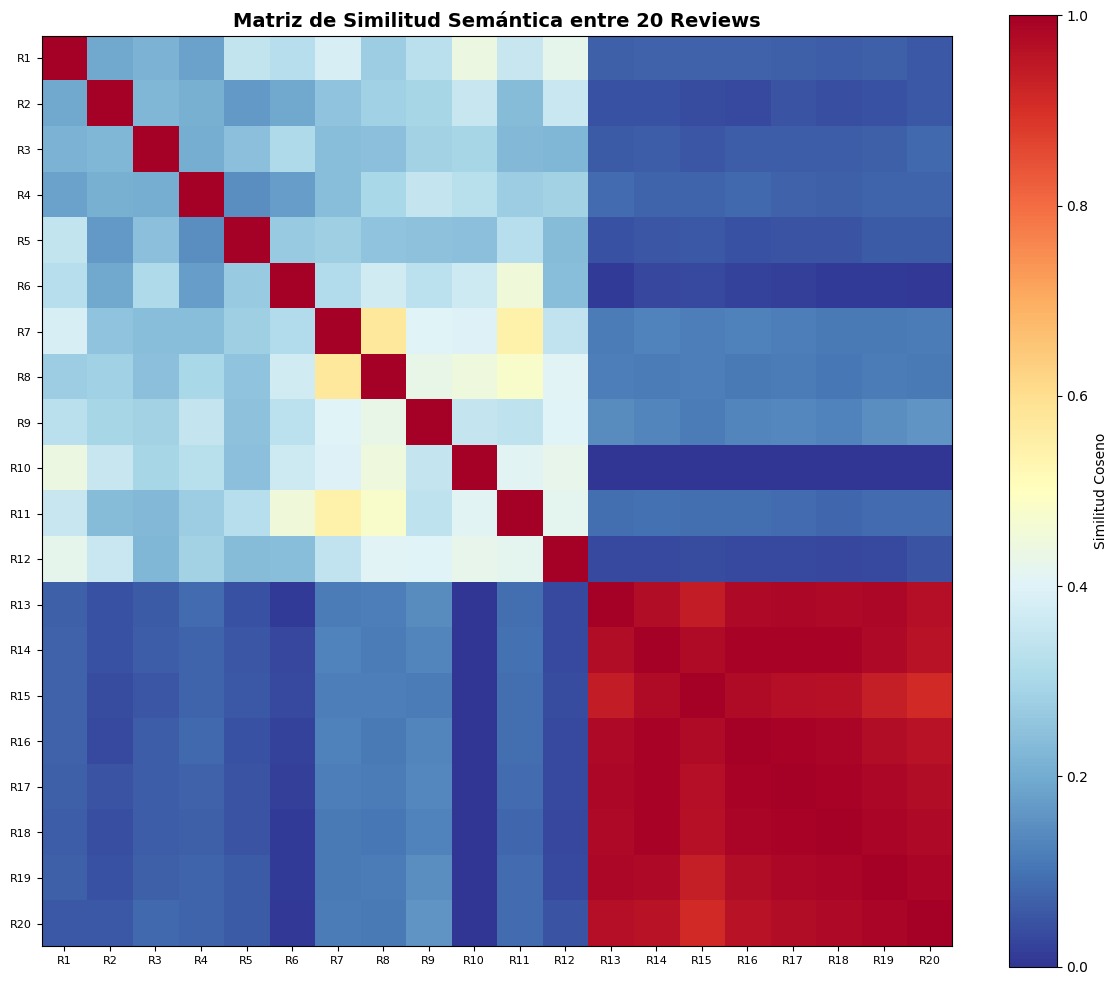

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

# Calcular matriz de similitud coseno
sim_matrix = cosine_similarity(embeddings_20)

# Convertir a DataFrame para visualización
df_sim = pd.DataFrame(
    sim_matrix,
    columns=[f"R{i+1}" for i in range(20)],
    index=[f"R{i+1}" for i in range(20)]
)

# Visualizar heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sim_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)

# Add labels
ax.set_xticks(range(20))
ax.set_yticks(range(20))
ax.set_xticklabels([f"R{i+1}" for i in range(20)], fontsize=8)
ax.set_yticklabels([f"R{i+1}" for i in range(20)], fontsize=8)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Similitud Coseno')

ax.set_title('Matriz de Similitud Semántica entre 20 Reviews', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/05_embeddings/matriz_similitud_20_peliculas.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Mostrar las 5 parejas más similares
pairs = []
for i in range(20):
    for j in range(i+1, 20):
        pairs.append((i, j, sim_matrix[i, j]))

pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 5 parejas más similares semánticamente:")
for i, j, sim in pairs[:5]:
    print(f"  {labels_20[i]} <-> {labels_20[j]}: similitud = {sim:.3f}")
    print()

Top 5 parejas más similares semánticamente:
  The Star Wars Holiday Special <-> Batman & Robin: similitud = 0.991

  A Serbian Film <-> Batman & Robin: similitud = 0.991

  Catwoman <-> The Star Wars Holiday Special: similitud = 0.990

  A Serbian Film <-> The Star Wars Holiday Special: similitud = 0.990

  A Serbian Film <-> Catwoman: similitud = 0.989



## 11. Conclusiones

### Evolución de los Embeddings de Texto

| Modelo | Año | Tipo | Contextual | OOV | Dim |
|--------|-----|------|------------|-----|-----|
| Word2Vec | 2013 | Estático | No | No | 100-300 |
| GloVe | 2014 | Estático | No | No | 50-300 |
| FastText | 2017 | Estático + subwords | No | Sí | 100-300 |
| SBERT | 2019 | Contextual | Sí | Sí (tokenizer) | 384-768 |
| BERT | 2019 | Contextual | Sí | Sí (tokenizer) | 768 |

### Hallazgos Clave

1. **Embeddings estáticos** (Word2Vec, GloVe, FastText) capturan similitud léxica pero no semántica contextual.
2. **FastText** supera a Word2Vec y GloVe al manejar palabras desconocidas mediante n-gramas de caracteres.
3. **Modelos contextuales** (SBERT, BERT) generan espacios latentes con mayor separabilidad semántica.
4. **PCA** revela que incluso en 2D, los modelos contextuales logran clusters más coherentes.
5. **El mapa de proximidad** muestra cómo reviews con sentimiento similar tienden a agruparse en el espacio semántico.

> [!TIP]
> Para aplicaciones de producción, **Sentence-BERT** ofrece el mejor balance entre calidad de embeddings y eficiencia computacional.

In [ ]:
# Celda vacía para experimentación del estudiante
# Espacio para explorar embeddings de palabras específicas

# Ejemplo: encontrar palabras similares en cada modelo
# w2v_model.wv.most_similar('movie')
# glove_model.most_similar('movie')
# ft_model.wv.most_similar('movie')